In [ ]:
#!pip install scikit-learn
#!pip install pandas
#!pip install matplotlib

<h1 align="center"> Lingüística Computacional - MIARFID</h1>
<h1 align="center"> Laboratorio 4 - Clasificación de Textos</h1>

# Indicad el nombre de lxs estudiantes que realizan la entrega
## Estudiante 1:
## Estudiante 2:

# Introducción

En esta sesión vamos a crear y evaluar distintos modelos para una tarea de clasificación supervisada de textos. 

Recorreremos todas las fases del proceso:

- carga de los datos
- tokenización y extracción de características
- entrenamiento del modelo
- evaluación del modelo con un dataset de test

---


## ¿Qué características tiene la tarea?

Para esta sesión utilizaremos el corpus de la tarea 1 propuesta en la competición [TASS 2017](http://tass.sepln.org/2017/). Esta tarea se centra en la clasificación de tweets en función de su polaridad. No hay particion de desarrollo así que tendremos que *fabricarnos* una. Los datos están anotados con 6 etiquetas de polaridad diferentes (P, P+, N, N+, NEU, NONE); se trata, por tanto, de una clasificación multiclase.

  - Las etiquetas __P__ y __P+__ indican que el tweet transmite una opinión/sentimiento general "positivo" en diferente grado.
  - Las etiquetas __N__ y __N+__ indican que el tweet transmite una opinión/sentimiento general "negativo" en diferente grado.
  - La etiqueta __NONE__ indica que el tweet no transmite globalmente ninguna opinión o sentimiento.
  - La etiqueta __NEU__ indica que el tweet transmite sentimiento tanto positivo como negativo y de alguna manera esos sentimientos se neutralizan.


Los ficheros que se tenéis disponibles son:

- __tass_generalcorpus_train.tsv__: es el fichero etiquetado para entrenamiento. El el mismo fichero para la tarea 1 (la que abordaremos en esta práctica) y la tarea2. Cada linea del fichero es una muestra con cuatro campos separados por tabulador ("\t"): el id del tweet, el texto del tweet, la etiqueta de la tarea 1 y la etiqueta de la tarea 2 (esta no nos interesa).

- __ElhPolar_esV1.lex__ (opcional): se trata de un diccionario de polaridad que puede ser útil para algunos modelos.
---

# Cosas previas

In [4]:
import collections
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics
import os

LOAD_STOP_WORDS = True # load stop_words from nltk
DEV_PART = 0.15

corpus_dir = "TASS"
training_filename = "tass_generalcorpus_train.tsv"
global_results = {} # almacenar los resultados de todos los clasificadores


if LOAD_STOP_WORDS:
    import nltk # opcional    
    try:
        nltk.corpus.stopwords.words('spanish')
    except LookupError:
        nltk.download('stopwords')
        nltk.download('punkt')
    stop_words = set(nltk.corpus.stopwords.words('spanish'))
else:
    stop_words = []

def evaluation_result(y_true, y_pred, clases):
    hits = sum([1 if t==p else 0 for t,p in zip(y_true, y_pred)])
    print("Hits:", hits)
    cm = metrics.confusion_matrix(y_true, y_pred, labels=clases)
    print(metrics.classification_report(y_true, y_pred, zero_division=0, digits=4))
    creport = metrics.classification_report(y_true, y_pred, zero_division=0, digits=6, output_dict=True)
    disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
    disp.plot()
    plt.show()
    return creport

# Ejercicio 0. Cargar los datos de aprendizaje

Carga el fichero "_tass_generalcorpus_train.tsv_" y crea una partición para entrenamiento y otra para desarrollo. Las particiones deben ser disjuntas y la de desarrollo debe suponer una **DEV_PART** parte del corpus original.

Tokeniza las particiones obtén estadísticas tanto del contenido textual (número de muestras, número de tokens, distribución de las etiquetas, ...) como de la distribución de etiquetas. Para realizar la tokenización puedes utilizar el tokenizador de nltk para Twitter (nltk.tokenize.casual.TweetTokenizer), tu tokenizador de prácticas anteriores o cualquier otro tokenizador que consideres.

Puesto que no tenemos demasiadas etiquetas de entrenamiento y muchas clases (6) vamos a unir las etiquetas positivas (**P**, **P+**) y por otra parte las negativas (**N**, **N+**).

Nota: algunes extractores de características tienen su propio tokenizador, debes tener esto en cuenta si los quieres utilizar.

In [3]:
def load_corpus(filename):
    raw_text = [] # lista con el texto de los tweets sin procesar
    labels = [] # lista de etiquetas
    # COMPLETAR

    return raw_text, labels

def load_dic(filename):
    d = {} # clave la palabra, valor su polaridad
    # COMPLETAR
    
    return d


def show_stats(txtlst, stopwords=None):
    "txtlst es una lista de cadenas"
    sl = txtlst
    nsamples = len(sl)
    nwords = sum(len(s.split()) for s in sl)
    print("Número de muestras:", nsamples)
    print("Número de palabras:", nwords)
    print(f"Palabras por muestra: {nwords/nsamples:.3f}")
    if stopwords is not None:
        # COMPLETAR      

raw_train, y_train = load_corpus(os.path.join(corpus_dir, training_filename))

# COMPLETAR

CLASES

Training original
-----------------
'N': 1120 (18.2%)
'N+': 757 (12.3%)
'NEU': 588 (9.6%)
'NONE': 1207 (19.7%)
'P': 1097 (17.9%)
'P+': 1368 (22.3%)

Development original
--------------------
'N': 215 (19.9%)
'N+': 90 (8.3%)
'NEU': 82 (7.6%)
'NONE': 276 (25.5%)
'P': 135 (12.5%)
'P+': 284 (26.2%)

Training colapsado
------------------
'N': 1877 (30.6%)
'NEU': 588 (9.6%)
'NONE': 1207 (19.7%)
'P': 2465 (40.2%)

Development colapsado
---------------------
'N': 305 (28.2%)
'NEU': 82 (7.6%)
'NONE': 276 (25.5%)
'P': 419 (38.7%)


TEXTO
=====

Training RAW
------------
Número de muestras: 6137
Número de palabras: 98483
Palabras por muestra: 16.047
Número de palabras sin stop words: 64434
Palabras por muestra sin stop words: 10.499

Training Tokenized
------------------
Número de muestras: 6137
Número de palabras: 90060
Palabras por muestra: 14.675
Número de palabras sin stop words: 50001
Palabras por muestra sin stop words: 8.147

Development RAW
---------------
Número de muestras: 1082

In [ ]:
def load_corpus(filename):
    raw_text = [] # lista con el texto de los tweets sin procesar
    labels = [] # lista de etiquetas
    # COMPLETAR

    return raw_text, labels

def load_dic(filename):
    d = {} # clave la palabra, valor su polaridad
    # COMPLETAR
    
    return d


def show_stats(txtlst, stopwords=None):
    "txtlst es una lista de cadenas"
    sl = txtlst
    nsamples = len(sl)
    nwords = sum(len(s.split()) for s in sl)
    print("Número de muestras:", nsamples)
    print("Número de palabras:", nwords)
    print(f"Palabras por muestra: {nwords/nsamples:.3f}")
    if stopwords is not None:
        # COMPLETAR      

raw_train, y_train = load_corpus(os.path.join(corpus_dir, training_filename))

# COMPLETAR

CLASES

Training original
-----------------
'N': 1146 (18.7%)
'N+': 688 (11.2%)
'NEU': 556 (9.1%)
'NONE': 1251 (20.4%)
'P': 1067 (17.4%)
'P+': 1429 (23.3%)

Development original
--------------------
'N': 189 (17.5%)
'N+': 159 (14.7%)
'NEU': 114 (10.5%)
'NONE': 232 (21.4%)
'P': 165 (15.2%)
'P+': 223 (20.6%)

Training colapsado
------------------
'N': 1834 (29.9%)
'NEU': 556 (9.1%)
'NONE': 1251 (20.4%)
'P': 2496 (40.7%)

Development colapsado
---------------------
'N': 348 (32.2%)
'NEU': 114 (10.5%)
'NONE': 232 (21.4%)
'P': 388 (35.9%)

TEXTO

Training RAW
------------
Número de muestras: 6137
Número de palabras: 98671
Palabras por muestra: 16.078
Número de palabras sin stop words: 60172
Palabras por muestra sin stop words: 9.805

Training Tokenized
------------------
Número de muestras: 6137
Número de palabras: 117124
Palabras por muestra: 19.085
Número de palabras sin stop words: 76989
Palabras por muestra sin stop words: 12.545

Development RAW
---------------
Número de muestras: 1082

# Ejercicio 1. Naïve Bayes de sklearn
 
La librería scikit-learn dispone de su propia implementación del modelo [Naïve Bayes](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html). En este ejercicio vamos a aprender un modelo con los datos de entrenamiento y testear los resultados.

Todos los modelos de la librería scikit-learn disponene de dos métodos para entrenar y predecir etiquetas:

- __fit(X, y)__. Aprende el clasificador utilizando las características _X_ y las etiquetas _y_. En nuestro caso _X_ será un numpy.array con tantas filas como muestras de entrenamiento y tantas columnas como características, mientras que _y_ será una lista de cadenas.

- __predict(X)__. Devuelve las etiquetas más probables para _X_. _X_ será un numpy.array. El método devuelve una lista de cadenas con las etiquetas predichas.


El constructor de la clase MultinomialNB dispone de dos parámetros interesantes:

- alpha: define el valor de alfa que se utilizará en el suavizado
- fit_prior: indica si se deben aprender las probabilidades a priori de las clases. Si es False todas las clases son equiprobables a priori.

Aprende al menos un clasificador Naïve Bayes utilizando la librería scikit-learn y evalúa el resultado con la partición de validación. Puedes aprender múltiples modelos con diferentes tokenizaciones de los datos. También puedes probar con o sin las probabilidades a priori y diferentes valores de alpha.

Hits: 592
              precision    recall  f1-score   support

           N     0.4794    0.7639    0.5891       305
         NEU     0.0000    0.0000    0.0000        82
        NONE     0.6923    0.1630    0.2639       276
           P     0.5925    0.7494    0.6617       419

    accuracy                         0.5471      1082
   macro avg     0.4410    0.4191    0.3787      1082
weighted avg     0.5412    0.5471    0.4897      1082



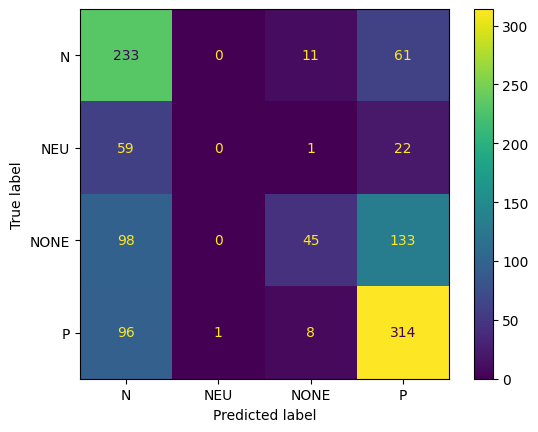

Hits: 600
              precision    recall  f1-score   support

           N     0.4683    0.7738    0.5834       305
         NEU     0.2500    0.0122    0.0233        82
        NONE     0.6889    0.2246    0.3388       276
           P     0.6219    0.7184    0.6667       419

    accuracy                         0.5545      1082
   macro avg     0.5073    0.4322    0.4030      1082
weighted avg     0.5675    0.5545    0.5108      1082



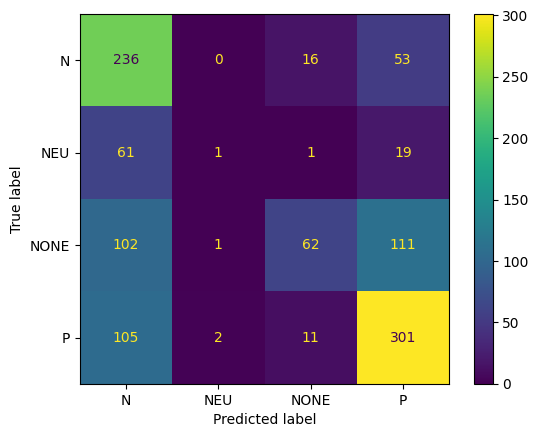

In [4]:
# definimos los datos de entrenamiento y de validación
train_samples = raw_train
valid_samples = raw_dev
labels = y_train

# 1r modelo
# obtenemos los counts de cada palabra en los datos de entrenamiento
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(train_samples).toarray()
# los counts de validación
X_valid = vectorizer.transform(valid_samples).toarray()
NB_model = MultinomialNB(alpha=1)
NB_model.fit(X_train, labels)
y_preds = NB_model.predict(X_valid)
result = evaluation_result(y_dev, y_preds, NB_model.classes_)
global_results["MultinomialNB-raw"] = result # almacenamos el resultado para la comparativa final

# 2o modelo
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(train_samples).toarray()
# los counts de validación
X_valid = vectorizer.transform(valid_samples).toarray()
NB_model = MultinomialNB(alpha=1, fit_prior=False)
NB_model.fit(X_train, labels)
y_preds = NB_model.predict(X_valid)
result = evaluation_result(y_dev, y_preds, NB_model.classes_)
global_results["MultinomialNB-raw-sin_apriori"] = result # almacenamos el resultado para la comparativa final


# Ejercicio 2. Tu propio Naïve Bayes

En este ejercicio debes construir tu propio modelo. Completa los métodos de la clase **MyNaiveBayes** y repite la experimentación anterior. 

Deberías obtener los mismos resultados.

Hits: 592
              precision    recall  f1-score   support

           N     0.4794    0.7639    0.5891       305
         NEU     0.0000    0.0000    0.0000        82
        NONE     0.6923    0.1630    0.2639       276
           P     0.5925    0.7494    0.6617       419

    accuracy                         0.5471      1082
   macro avg     0.4410    0.4191    0.3787      1082
weighted avg     0.5412    0.5471    0.4897      1082



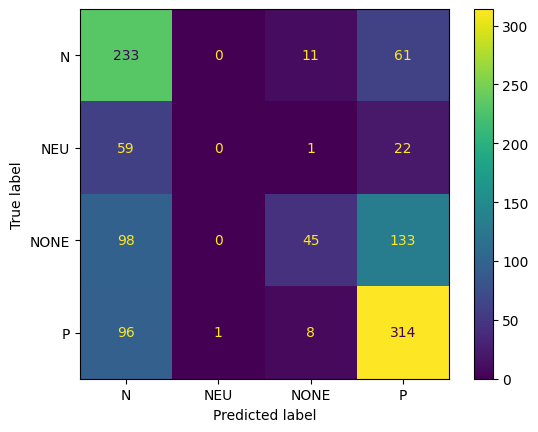

Hits: 600
              precision    recall  f1-score   support

           N     0.4683    0.7738    0.5834       305
         NEU     0.2500    0.0122    0.0233        82
        NONE     0.6889    0.2246    0.3388       276
           P     0.6219    0.7184    0.6667       419

    accuracy                         0.5545      1082
   macro avg     0.5073    0.4322    0.4030      1082
weighted avg     0.5675    0.5545    0.5108      1082



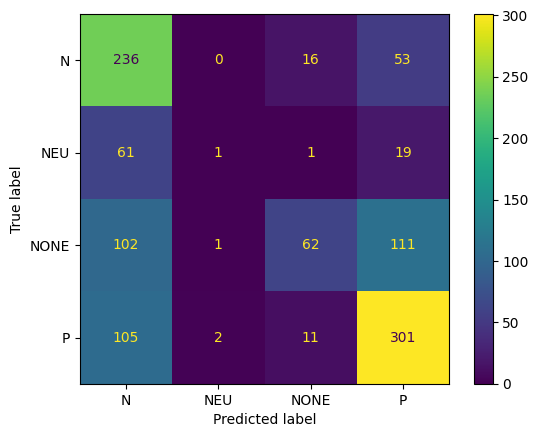

In [5]:
class MyNaiveBayes:
    def __init__(self, alpha=1.0, fit_prior=True):
        self.alpha = alpha
        self.fit_prior = fit_prior
        self.vocab_size_ = 0
        self.classes_ = []
        self.class_log_prior_ = {}  # log(P(c))
        self.feature_log_prob_ = {} # Feature Log-Likelihood Probability, log(P(xi|c))

    def fit(self, X, y):
        """
        counts debe ser un array de numpy
        """
        self.classes_ = list(sorted(set(y)))
        self.vocab_size_ = X.shape[1]

        # 1. compute a prior Log-prob, log(P(c))=count(c)/NDocs
        # COMPLETAR

        # 2. compute Log-Likelihood Probability, log(P(xi|c))=count(xi in c) / sum_all(count(xj in c))
        # COMPLETAR

    def predict(self, X):
        preds = []
        for sample in X:
            best_c, best_score = None, -np.inf
            # COMPLETAR
            preds.append(best_c)
        return preds

# 1r modelo
# obtenemos los counts de cada palabra en los datos de entrenamiento
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(train_samples).toarray()
# los counts de validación
X_valid = vectorizer.transform(valid_samples).toarray()
NB_model = MyNaiveBayes(alpha=1)
NB_model.fit(X_train, labels)
y_preds = NB_model.predict(X_valid)
result = evaluation_result(y_dev, y_preds, NB_model.classes_)
global_results["MyNaiveBayes-raw"] = result # almacenamos el resultado para la comparativa final

# 2o modelo
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(train_samples).toarray()
# los counts de validación
X_valid = vectorizer.transform(valid_samples).toarray()
NB_model = MyNaiveBayes(alpha=1, fit_prior=False)
NB_model.fit(X_train, labels)
y_preds = NB_model.predict(X_valid)
result = evaluation_result(y_dev, y_preds, NB_model.classes_)
global_results["MyNaiveBayes-raw-sin_apriori"] = result # almacenamos el resultado para la comparativa final


In [ ]:
# SOLUCIÓN EJERCICIO 2

class MyNaiveBayes:
    def __init__(self, alpha=1.0, fit_prior=True):
        self.alpha = alpha
        self.fit_prior = fit_prior
        self.vocab_size_ = 0
        self.classes_ = []
        self.class_log_prior_ = {}  # log(P(c))
        self.feature_log_prob_ = {} # Feature Log-Likelihood Probability, log(P(xi|c))

    def fit(self, X, y):
        """
        counts debe ser un array de numpy
        """
        self.classes_ = list(sorted(set(y)))
        self.vocab_size_ = X.shape[1]

        # 1. compute a prior Log-prob, log(P(c))=count(c)/NDocs
        n_samples = X.shape[0]
        for c in self.classes_:
            n_c = sum(1 for label in y if label == c)
            if self.fit_prior:
                self.class_log_prior_[c] = np.log(n_c / n_samples)
            else:
                # Todas las clases son equiprobables
                self.class_log_prior_[c] = np.log(1.0 / len(self.classes_))

        # 2. compute Log-Likelihood Probability, log(P(xi|c))=count(xi in c) / sum_all(count(xj in c))
        for c in self.classes_:
            # Obtener todas las muestras de la clase c
            X_c = X[np.array(y) == c]
            
            # Suma de counts por feature para esta clase
            feature_count = X_c.sum(axis=0) + self.alpha
            
            # Total de counts para esta clase
            total_count = feature_count.sum()
            
            # Calcular log probabilidades
            self.feature_log_prob_[c] = np.log(feature_count / total_count)

    def predict(self, X):
        preds = []
        for sample in X:
            best_c, best_score = None, -np.inf
            
            for c in self.classes_:
                # Calcular log P(c) + sum(log P(xi|c))
                score = self.class_log_prior_[c]
                score += np.sum(sample * self.feature_log_prob_[c])
                
                if score > best_score:
                    best_score = score
                    best_c = c
            
            preds.append(best_c)
        return preds

# 1r modelo
# obtenemos los counts de cada palabra en los datos de entrenamiento
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(train_samples).toarray()
# los counts de validación
X_valid = vectorizer.transform(valid_samples).toarray()
NB_model = MyNaiveBayes(alpha=1)
NB_model.fit(X_train, labels)
y_preds = NB_model.predict(X_valid)
result = evaluation_result(y_dev, y_preds, NB_model.classes_)
global_results["MyNaiveBayes-raw"] = result # almacenamos el resultado para la comparativa final

# 2o modelo
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(train_samples).toarray()
# los counts de validación
X_valid = vectorizer.transform(valid_samples).toarray()
NB_model = MyNaiveBayes(alpha=1, fit_prior=False)
NB_model.fit(X_train, labels)
y_preds = NB_model.predict(X_valid)
result = evaluation_result(y_dev, y_preds, NB_model.classes_)
global_results["MyNaiveBayes-raw-sin_apriori"] = result # almacenamos el resultado para la comparativa final

# Ejercicio 3. Naïve Bayes con tfidf

En el modelo teórico Naïve Bayes se calcula la verosimilitud de las palabras en la clase como:$$p(w_k|c_j) = \frac{n_k+\alpha}{n+|V|\alpha}$$ donde $n_k$ es el número de ocurrencias de $w_k$ en los documentos de la clase $c_j$ y $n$ es $\sum_{k=1}^{|V|} n_k$. 

Sin embargo, podemos sustituir $n_k$ por cualquier _métrica_ calculada sobre las apariciones de la palabra $w_k$ en la clase $c_j$, por ejemplo, los valores _tfidf_. Reformulando la verosimiliud como:

\begin{equation}
    p(w_k|c_j) = \frac{tfidf_k+\alpha}{tfidf+|V|\alpha}
\end{equation}
donde $tfidf_k$ es la suma de todos los valores _tfidf_ de la palabra $w_k$ en los documentos de la clase $c_j$ y $tfidf$ es $\sum_{k=1}^{|V|} tfidf_k$. 

Implementar esto es tan simple como sustituir el vectorizador de contadores por un contador tfidf.
Aprende varios modelos Naïve Bayes utilizando contadores _tfidf_ y evalúalos contra el corpus de validación. **Utiliza tu propia implementación del clasificador Naïve Bayes**.


Hits: 594
              precision    recall  f1-score   support

           N     0.5238    0.7213    0.6069       305
         NEU     0.0488    0.0244    0.0325        82
        NONE     0.5923    0.2790    0.3793       276
           P     0.6008    0.7041    0.6484       419

    accuracy                         0.5490      1082
   macro avg     0.4414    0.4322    0.4168      1082
weighted avg     0.5351    0.5490    0.5214      1082



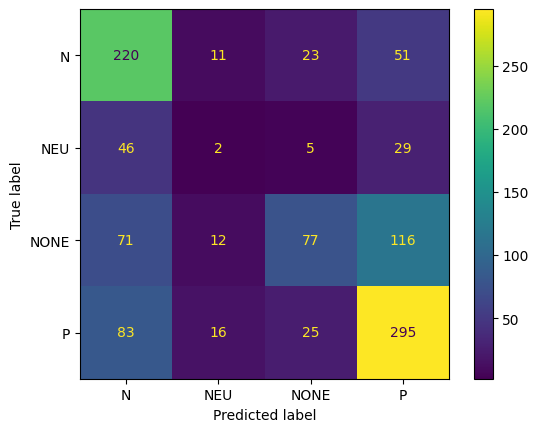

Hits: 568
              precision    recall  f1-score   support

           N     0.5053    0.6262    0.5593       305
         NEU     0.0794    0.1220    0.0962        82
        NONE     0.5723    0.3442    0.4299       276
           P     0.6602    0.6492    0.6546       419

    accuracy                         0.5250      1082
   macro avg     0.4543    0.4354    0.4350      1082
weighted avg     0.5501    0.5250    0.5281      1082



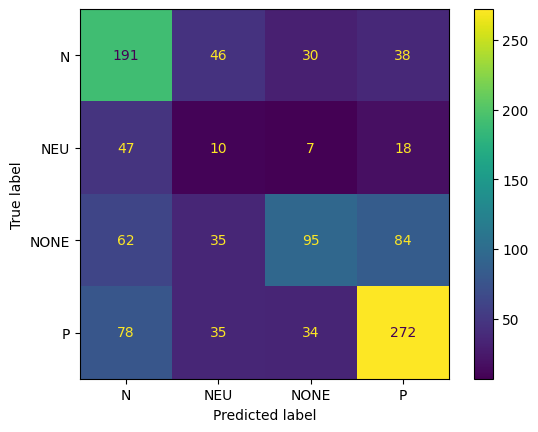

In [6]:
# 1r modelo
# obtenemos los counts de cada palabra en los datos de entrenamiento
vectorizer = TfidfVectorizer()

# COMPLETAR


In [ ]:
# SOLUCIÓN EJERCICIO 3

# 1r modelo con TF-IDF
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_samples).toarray()
X_valid = vectorizer.transform(valid_samples).toarray()
NB_model = MyNaiveBayes(alpha=1)
NB_model.fit(X_train, labels)
y_preds = NB_model.predict(X_valid)
result = evaluation_result(y_dev, y_preds, NB_model.classes_)
global_results["MyNaiveBayes-tfidf"] = result

# 2o modelo con TF-IDF sin a priori
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_samples).toarray()
X_valid = vectorizer.transform(valid_samples).toarray()
NB_model = MyNaiveBayes(alpha=1, fit_prior=False)
NB_model.fit(X_train, labels)
y_preds = NB_model.predict(X_valid)
result = evaluation_result(y_dev, y_preds, NB_model.classes_)
global_results["MyNaiveBayes-tfidf-sin_apriori"] = result

# 3r modelo con TF-IDF y sin stopwords
vectorizer = TfidfVectorizer(stop_words=list(stop_words))
X_train = vectorizer.fit_transform(train_samples).toarray()
X_valid = vectorizer.transform(valid_samples).toarray()
NB_model = MyNaiveBayes(alpha=1)
NB_model.fit(X_train, labels)
y_preds = NB_model.predict(X_valid)
result = evaluation_result(y_dev, y_preds, NB_model.classes_)
global_results["MyNaiveBayes-tfidf-sin_stopwords"] = result

# Ejercicio 4. Regresión Logística

La librería scikit-learn dispone de múltiples clasificadores entre los que se incluye un modelo de [Regresión Logística](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). Consulta la documentación y entrena modelos de Regresión Logística con diferentes configuraciones de parámetros.


Hits: 610
              precision    recall  f1-score   support

           N     0.4823    0.6689    0.5604       305
         NEU     0.0000    0.0000    0.0000        82
        NONE     0.6138    0.3225    0.4228       276
           P     0.6191    0.7566    0.6810       419

    accuracy                         0.5638      1082
   macro avg     0.4288    0.4370    0.4161      1082
weighted avg     0.5323    0.5638    0.5295      1082



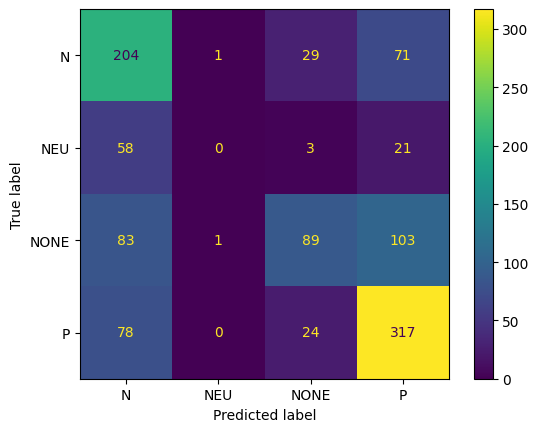

Hits: 610
              precision    recall  f1-score   support

           N     0.4823    0.6689    0.5604       305
         NEU     0.0000    0.0000    0.0000        82
        NONE     0.6138    0.3225    0.4228       276
           P     0.6191    0.7566    0.6810       419

    accuracy                         0.5638      1082
   macro avg     0.4288    0.4370    0.4161      1082
weighted avg     0.5323    0.5638    0.5295      1082



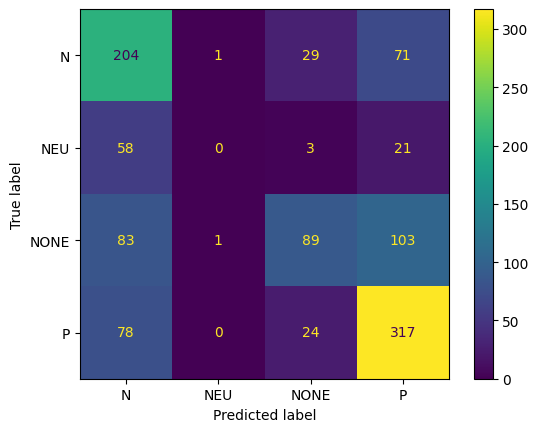

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)

vectorizer = TfidfVectorizer()

# COMPLETAR

model.fit(X_train, labels)
y_preds = model.predict(X_valid)
result = evaluation_result(y_dev, y_preds, model.classes_)
global_results["LogisticRegression-raw-lbfgs"] = result # almacenamos el resultado para la comparativa final


In [ ]:
# SOLUCIÓN EJERCICIO 4

from sklearn.linear_model import LogisticRegression

# 1r modelo - Regresión Logística con TF-IDF
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_samples).toarray()
X_valid = vectorizer.transform(valid_samples).toarray()

model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(X_train, labels)
y_preds = model.predict(X_valid)
result = evaluation_result(y_dev, y_preds, model.classes_)
global_results["LogisticRegression-tfidf-lbfgs"] = result

# 2o modelo - Con regularización más fuerte
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, C=0.5)
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_samples).toarray()
X_valid = vectorizer.transform(valid_samples).toarray()
model.fit(X_train, labels)
y_preds = model.predict(X_valid)
result = evaluation_result(y_dev, y_preds, model.classes_)
global_results["LogisticRegression-tfidf-lbfgs-C0.5"] = result

# 3r modelo - Sin stopwords
vectorizer = TfidfVectorizer(stop_words=list(stop_words))
X_train = vectorizer.fit_transform(train_samples).toarray()
X_valid = vectorizer.transform(valid_samples).toarray()
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(X_train, labels)
y_preds = model.predict(X_valid)
result = evaluation_result(y_dev, y_preds, model.classes_)
global_results["LogisticRegression-tfidf-sin_stopwords"] = result

# Ejercicio 5. Otros clasificadores

Prueba diferentes clasificadores disponibles en la librería scikit-learn.

Por ejemplo:

- KNeighborsClassifier.
- Support Vector Classifier.
- Multi-layer Perceptron classifier.
- DecisionTreeClassifier.
- RandomForestClassifier.
- ...

Puedes probar diferentes clasificadores, diferentes parámetros de entrenamiento para el mismo clasificador y diferentes extractores de características.


classifiers A
Hits: 606
              precision    recall  f1-score   support

           N     0.4987    0.6492    0.5641       305
         NEU     0.1081    0.0488    0.0672        82
        NONE     0.5625    0.3587    0.4381       276
           P     0.6462    0.7279    0.6846       419

    accuracy                         0.5601      1082
   macro avg     0.4539    0.4461    0.4385      1082
weighted avg     0.5425    0.5601    0.5410      1082



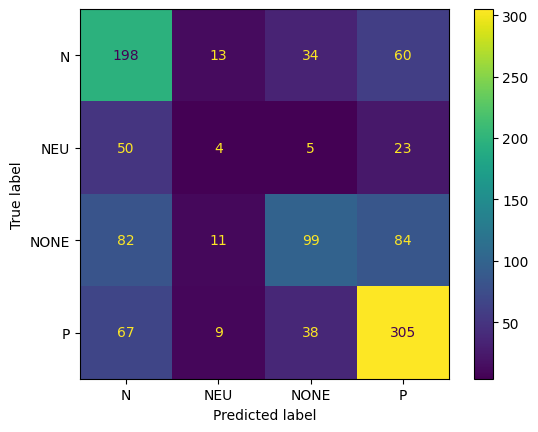

classifiers B
Hits: 302
              precision    recall  f1-score   support

           N     0.6000    0.0098    0.0194       305
         NEU     0.0000    0.0000    0.0000        82
        NONE     0.2577    0.9674    0.4070       276
           P     0.7805    0.0764    0.1391       419

    accuracy                         0.2791      1082
   macro avg     0.4096    0.2634    0.1414      1082
weighted avg     0.5371    0.2791    0.1632      1082



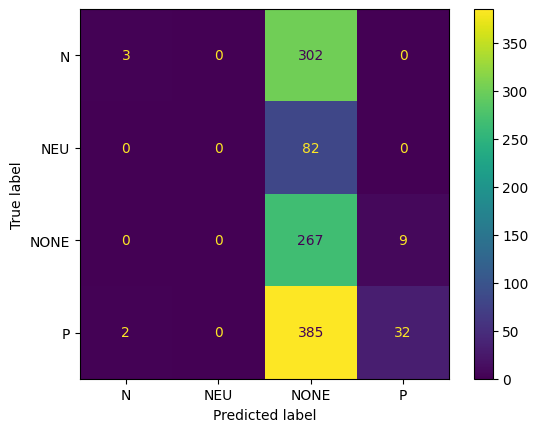

classifiers C
Hits: 456
              precision    recall  f1-score   support

           N     0.3929    0.3967    0.3948       305
         NEU     0.1452    0.1098    0.1250        82
        NONE     0.4453    0.3986    0.4207       276
           P     0.4645    0.5155    0.4887       419

    accuracy                         0.4214      1082
   macro avg     0.3620    0.3551    0.3573      1082
weighted avg     0.4152    0.4214    0.4173      1082



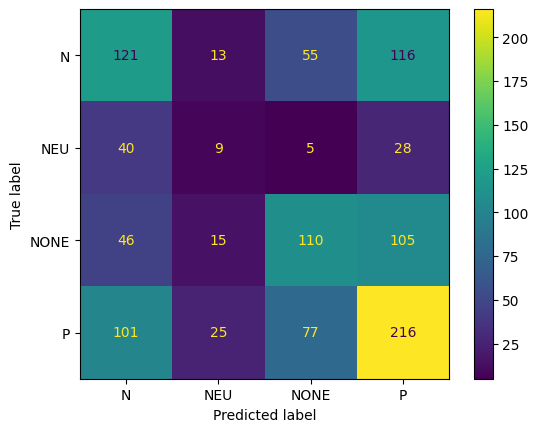

classifiers D
Hits: 554
              precision    recall  f1-score   support

           N     0.4661    0.5180    0.4907       305
         NEU     0.0000    0.0000    0.0000        82
        NONE     0.5723    0.3587    0.4410       276
           P     0.5211    0.7088    0.6006       419

    accuracy                         0.5120      1082
   macro avg     0.3898    0.3964    0.3831      1082
weighted avg     0.4791    0.5120    0.4834      1082



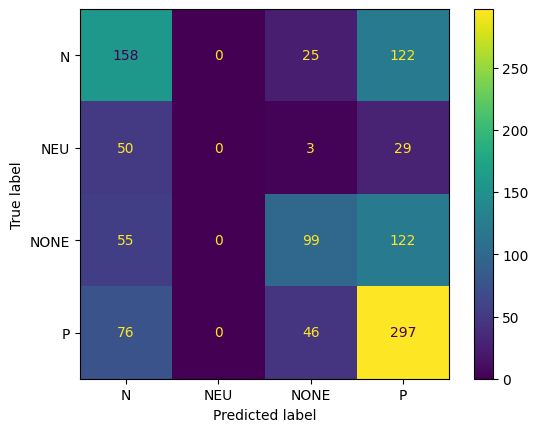

classifiers E
Hits: 560
              precision    recall  f1-score   support

           N     0.5030    0.5508    0.5258       305
         NEU     0.0845    0.0732    0.0784        82
        NONE     0.4569    0.3841    0.4173       276
           P     0.6292    0.6683    0.6481       419

    accuracy                         0.5176      1082
   macro avg     0.4184    0.4191    0.4174      1082
weighted avg     0.5084    0.5176    0.5116      1082



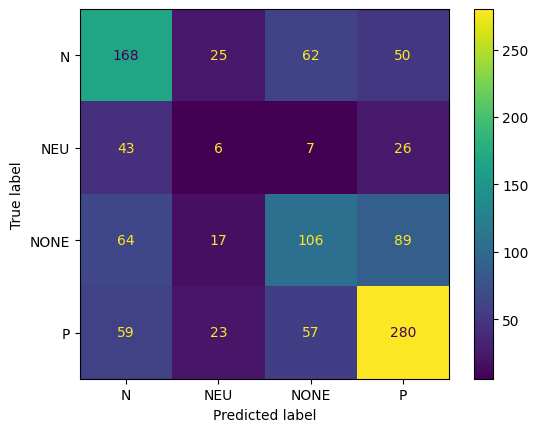

classifiers F
Hits: 515
              precision    recall  f1-score   support

           N     0.4213    0.5180    0.4647       305
         NEU     0.1658    0.3780    0.2305        82
        NONE     0.5324    0.4167    0.4675       276
           P     0.6941    0.5036    0.5837       419

    accuracy                         0.4760      1082
   macro avg     0.4534    0.4541    0.4366      1082
weighted avg     0.5359    0.4760    0.4937      1082



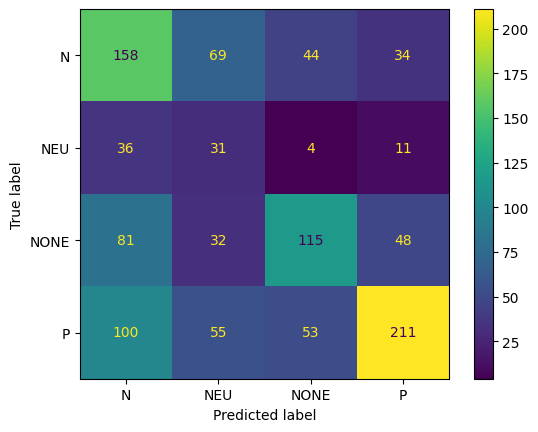

DummyClassifier
Hits: 419
              precision    recall  f1-score   support

           N     0.0000    0.0000    0.0000       305
         NEU     0.0000    0.0000    0.0000        82
        NONE     0.0000    0.0000    0.0000       276
           P     0.3872    1.0000    0.5583       419

    accuracy                         0.3872      1082
   macro avg     0.0968    0.2500    0.1396      1082
weighted avg     0.1500    0.3872    0.2162      1082



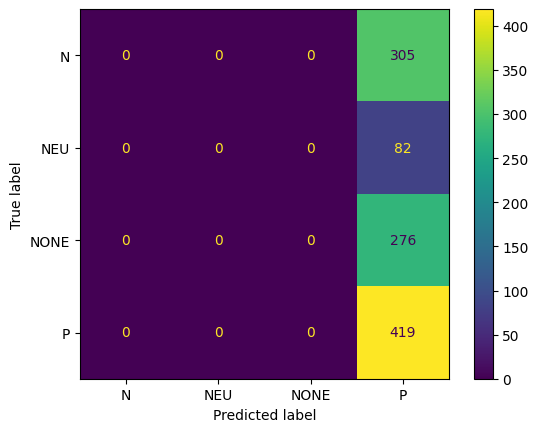

Hits: 600
              precision    recall  f1-score   support

           N     0.4974    0.6361    0.5583       305
         NEU     0.1562    0.0610    0.0877        82
        NONE     0.5385    0.3804    0.4459       276
           P     0.6366    0.7064    0.6697       419

    accuracy                         0.5545      1082
   macro avg     0.4572    0.4460    0.4404      1082
weighted avg     0.5359    0.5545    0.5371      1082



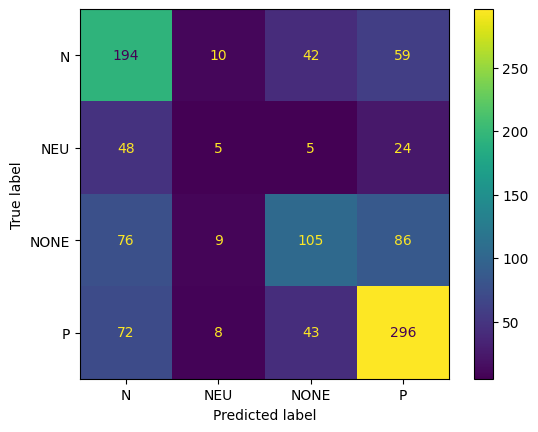

Hits: 510
              precision    recall  f1-score   support

           N     0.4738    0.5049    0.4889       305
         NEU     0.0333    0.0122    0.0179        82
        NONE     0.3974    0.6594    0.4959       276
           P     0.6431    0.4129    0.5029       419

    accuracy                         0.4713      1082
   macro avg     0.3869    0.3974    0.3764      1082
weighted avg     0.4865    0.4713    0.4604      1082



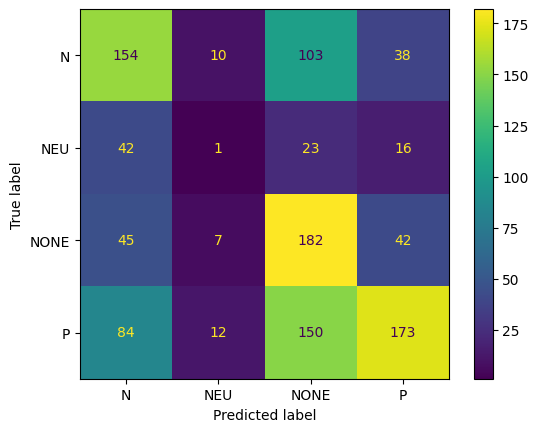

Hits: 423
              precision    recall  f1-score   support

           N     0.3947    0.3934    0.3941       305
         NEU     0.1014    0.0854    0.0927        82
        NONE     0.3633    0.3949    0.3785       276
           P     0.4572    0.4463    0.4517       419

    accuracy                         0.3909      1082
   macro avg     0.3292    0.3300    0.3292      1082
weighted avg     0.3887    0.3909    0.3896      1082



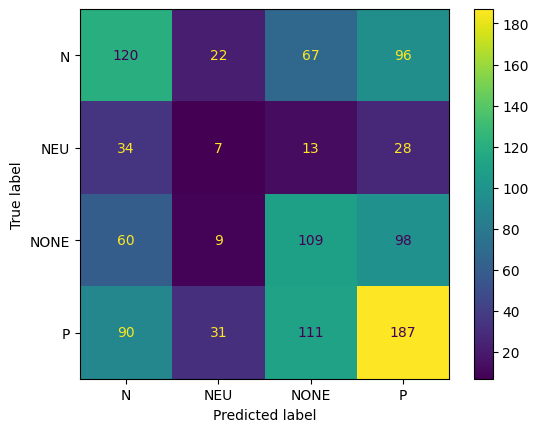

Hits: 542
              precision    recall  f1-score   support

           N     0.4622    0.5410    0.4985       305
         NEU     0.0000    0.0000    0.0000        82
        NONE     0.5049    0.3768    0.4315       276
           P     0.5260    0.6516    0.5821       419

    accuracy                         0.5009      1082
   macro avg     0.3733    0.3923    0.3780      1082
weighted avg     0.4628    0.5009    0.4760      1082



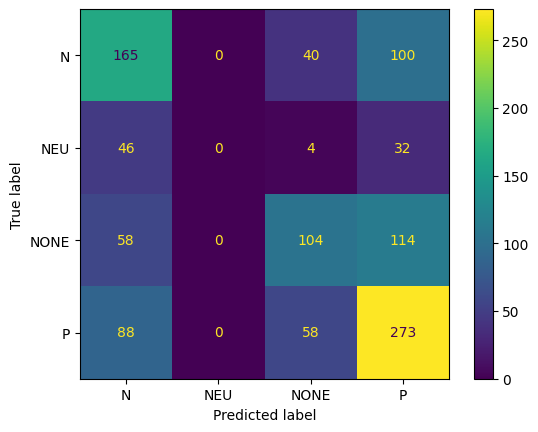

Hits: 576
              precision    recall  f1-score   support

           N     0.5133    0.5705    0.5404       305
         NEU     0.0735    0.0610    0.0667        82
        NONE     0.4854    0.4203    0.4505       276
           P     0.6445    0.6706    0.6573       419

    accuracy                         0.5323      1082
   macro avg     0.4292    0.4306    0.4287      1082
weighted avg     0.5236    0.5323    0.5268      1082



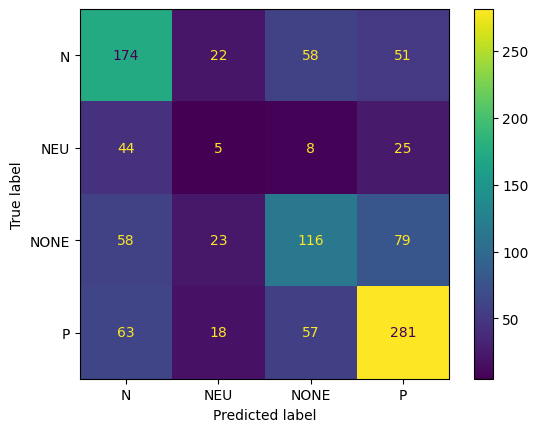

Hits: 467
              precision    recall  f1-score   support

           N     0.4104    0.4656    0.4363       305
         NEU     0.1566    0.3780    0.2214        82
        NONE     0.4142    0.4022    0.4081       276
           P     0.6778    0.4368    0.5312       419

    accuracy                         0.4316      1082
   macro avg     0.4147    0.4206    0.3992      1082
weighted avg     0.4957    0.4316    0.4496      1082



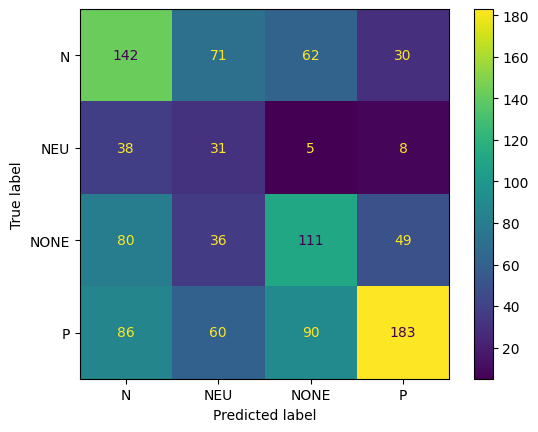

Hits: 419
              precision    recall  f1-score   support

           N     0.0000    0.0000    0.0000       305
         NEU     0.0000    0.0000    0.0000        82
        NONE     0.0000    0.0000    0.0000       276
           P     0.3872    1.0000    0.5583       419

    accuracy                         0.3872      1082
   macro avg     0.0968    0.2500    0.1396      1082
weighted avg     0.1500    0.3872    0.2162      1082



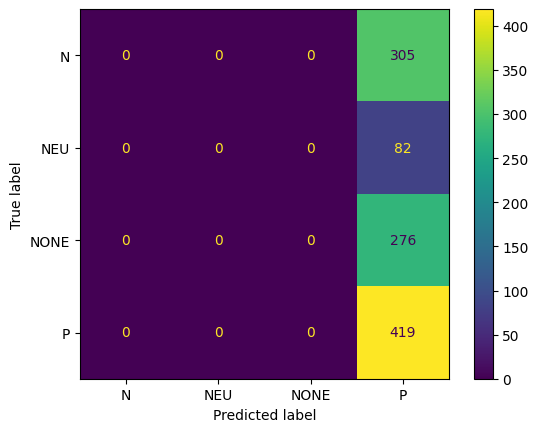

In [8]:

# COMPLETAR


In [ ]:
# SOLUCIÓN EJERCICIO 5

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. KNeighborsClassifier
print("=" * 50)
print("KNeighborsClassifier")
print("=" * 50)
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_samples).toarray()
X_valid = vectorizer.transform(valid_samples).toarray()
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, labels)
y_preds = model.predict(X_valid)
result = evaluation_result(y_dev, y_preds, clases)
global_results["KNeighborsClassifier-tfidf"] = result

# 2. Support Vector Classifier
print("\n" + "=" * 50)
print("SVC (Support Vector Classifier)")
print("=" * 50)
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_samples).toarray()
X_valid = vectorizer.transform(valid_samples).toarray()
model = SVC(kernel='linear', C=1.0)
model.fit(X_train, labels)
y_preds = model.predict(X_valid)
result = evaluation_result(y_dev, y_preds, clases)
global_results["SVC-linear-tfidf"] = result

# 3. Multi-layer Perceptron classifier
print("\n" + "=" * 50)
print("MLPClassifier")
print("=" * 50)
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_samples).toarray()
X_valid = vectorizer.transform(valid_samples).toarray()
model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
model.fit(X_train, labels)
y_preds = model.predict(X_valid)
result = evaluation_result(y_dev, y_preds, clases)
global_results["MLPClassifier-tfidf"] = result

# 4. DecisionTreeClassifier
print("\n" + "=" * 50)
print("DecisionTreeClassifier")
print("=" * 50)
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_samples).toarray()
X_valid = vectorizer.transform(valid_samples).toarray()
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, labels)
y_preds = model.predict(X_valid)
result = evaluation_result(y_dev, y_preds, clases)
global_results["DecisionTreeClassifier-tfidf"] = result

# 5. RandomForestClassifier
print("\n" + "=" * 50)
print("RandomForestClassifier")
print("=" * 50)
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_samples).toarray()
X_valid = vectorizer.transform(valid_samples).toarray()
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, labels)
y_preds = model.predict(X_valid)
result = evaluation_result(y_dev, y_preds, clases)
global_results["RandomForestClassifier-tfidf"] = result

# 6. RandomForestClassifier con más árboles
print("\n" + "=" * 50)
print("RandomForestClassifier (200 árboles)")
print("=" * 50)
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_samples).toarray()
X_valid = vectorizer.transform(valid_samples).toarray()
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, labels)
y_preds = model.predict(X_valid)
result = evaluation_result(y_dev, y_preds, clases)
global_results["RandomForestClassifier-200-tfidf"] = result

# Informe final

In [9]:
import pandas as pd

def show_final_report(all_results, labs=[], sort=True):
    info = {}   
    for name, report in all_results.items():
        row = {}
        for lab in labs:
            row[f"{lab} (f1)"] = report[lab]['f1-score']            
        row['Accuracy'] = report['accuracy']
        row['Precision (macro)'] = report['macro avg']['precision']
        row['Recall (macro)'] = report['macro avg']['recall']
        row['F1-Score (macro)'] = report['macro avg']['f1-score']        
        info[name] = row
    df = pd.DataFrame(info).T
    df = df.round(6)
    df = df.sort_values(by='F1-Score (macro)', ascending=False)
    
    return df

In [10]:
show_final_report(global_results, clases)

,N (f1),NEU (f1),NONE (f1),P (f1),Accuracy,Precision (macro),Recall (macro),F1-Score (macro)
classifiers A2,0.558273,0.087719,0.445860,0.669683,0.554529,0.457177,0.445980,0.440384
classifiers A,0.564103,0.067227,0.438053,0.684624,0.560074,0.453884,0.446145,0.438502
classifiers F,0.464706,0.230483,0.467480,0.583679,0.475970,0.453399,0.454082,0.436587
MyNaiveBayes-raw-tfidf-sin_apriori,0.559297,0.096154,0.429864,0.654633,0.524954,0.454285,0.435387,0.434987
classifiers E2,0.540373,0.066667,0.450485,0.657310,0.532348,0.429164,0.430600,0.428709
classifiers E,0.525822,0.078431,0.417323,0.648148,0.517560,0.418403,0.419077,0.417431
MyNaiveBayes-raw-tfidf,0.606897,0.032520,0.379310,0.648352,0.548983,0.441428,0.432186,0.416770
LogisticRegression-raw-lbfgs,0.560440,0.000000,0.422803,0.680988,0.563771,0.428801,0.436970,0.416058
LogisticRegression-raw-saga,0.560440,0.000000,0.422803,0.680988,0.563771,0.428801,0.436970,0.416058
MyNaiveBayes-raw-sin_apriori,0.583436,0.023256,0.338798,0.666667,0.554529,0.507261,0.432245,0.403039


# Ejercicio Extra. Prueba la segunda tarea

Modifica la carga del corpus para utilizar la segunda etiqueta (tarea 2 del TASS). Entrena y testea modelos para esa tarea.

Si lo haces te darás cuenta que se trata de una tarea multietiqueta (cada muestra puede tener asignadas más de una clase) y debe tratarse de forma distinta. **Es todo un reto**.

# Ejercicio Extra2. Calculo de tiempos

Modifica el código donde sea necesario para poder comparar el tiempo de entrenamiento e inferencia de los modelos.